In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score





### zad 1

Pierwsze 5 wierszy danych
                                                                                                review  \
0  One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....   
1  A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...   
2  I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...   
3  Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...   
4  Petter Mattei's "Love in the Time of Money" is a visually stunning film to watch. Mr. Mattei off...   

  sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4  positive  

Liczba wierszy (recenzji): 50000
Liczba kolumn: 2

Informacje o strukturze i brakujących danych
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ----

C:\Users\bartek\AppData\Local\Temp\ipykernel_18560\3288791227.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


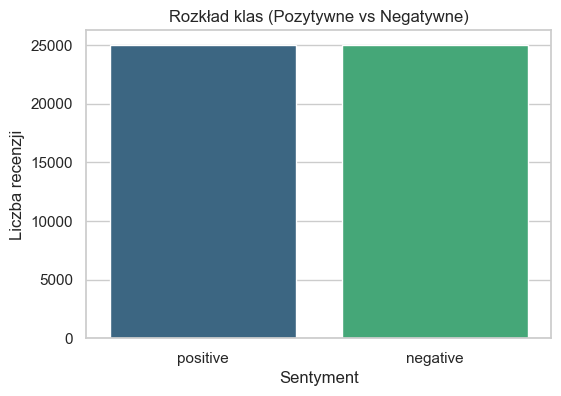


Statystyki długości tekstu
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: text_length, dtype: float64


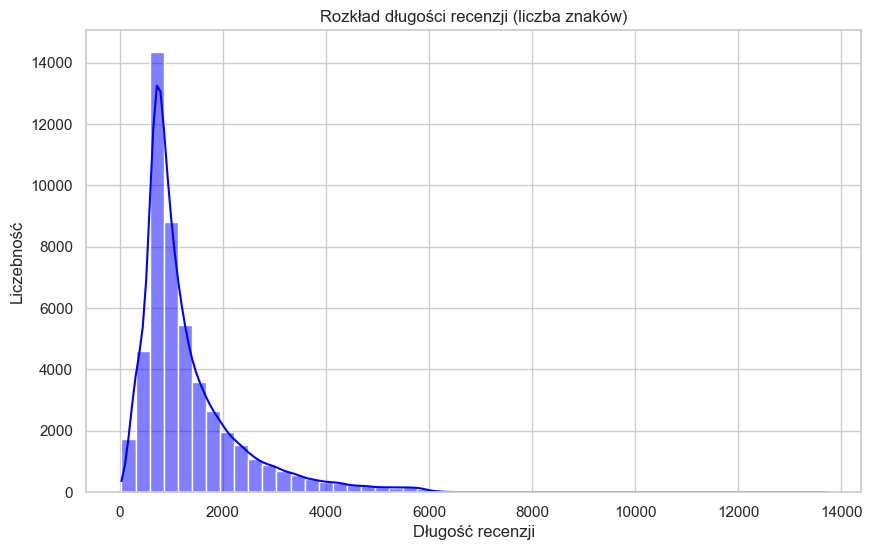

C:\Users\bartek\AppData\Local\Temp\ipykernel_18560\3288791227.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='text_length', data=df, palette='coolwarm')


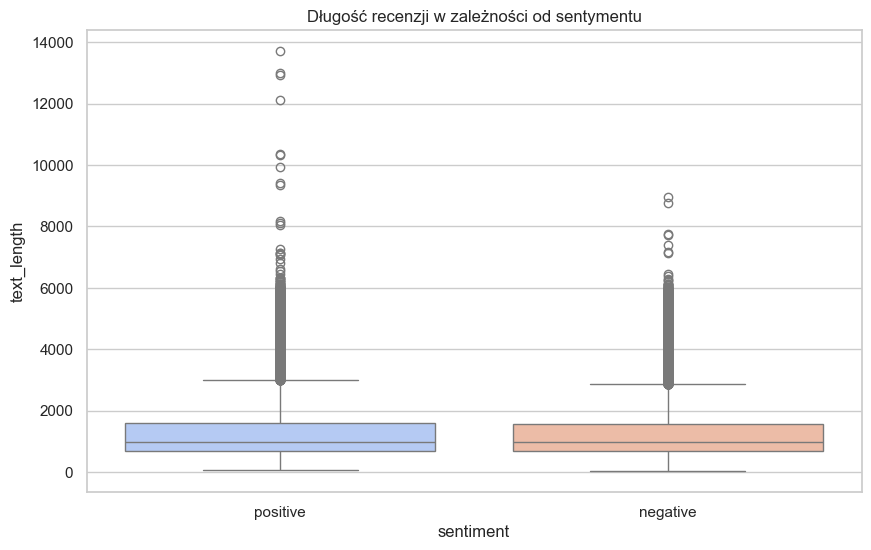

In [42]:
sns.set(style="whitegrid")

#wczytywanie danych z url
url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
df = pd.read_csv(url)


#wizualizacja danych
print("Pierwsze 5 wierszy danych")
print(df.head())
print(f"\nLiczba wierszy (recenzji): {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")

print("\nInformacje o strukturze i brakujących danych")
print(df.info())

#analiza rozkładu klas
print("\n--- 4. Rozkład klas (Wydźwięk) ---")
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

#wizualizacja 
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Rozkład klas (Pozytywne vs Negatywne)')
plt.xlabel('Sentyment')
plt.ylabel('Liczba recenzji')
plt.show()

#analiza długości tekstu
df['text_length'] = df['review'].apply(len)

print("\nStatystyki długości tekstu")
print(df['text_length'].describe())

# Wizualizacja rozkładu długości tekstu
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True, color='blue')
plt.title('Rozkład długości recenzji (liczba znaków)')
plt.xlabel('Długość recenzji')
plt.ylabel('Liczebność')
plt.show()

# Porównanie długości tekstu dla obu klas
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='text_length', data=df, palette='coolwarm')
plt.title('Długość recenzji w zależności od sentymentu')
plt.show()

### zad 2

In [43]:
#pobieramy listę stopwords, czyli słów bez znaczenia tj. and, a, the
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

#funkcja czyszcząca, przetwarza surowy tekst
#konwertuje na małe litery
#usuwa wszystko poza literami
#usuwa stop words
def clean_review(text):

    text = text.lower()
    
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    words = text.split()
    
    filtered_words = [word for word in words if word not in stop_words]
    
    return ' '.join(filtered_words)

#zastosowania fcji na danych
df['clean_review'] = df['review'].apply(clean_review)
#porównanie wyników przed i po
pd.set_option('display.max_colwidth', 100) 

print("Porównanie tekstu i oczyszczonego tekstu")
print(df[['review', 'clean_review']].head(3))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bartek\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Porównanie tekstu i oczyszczonego tekstu
                                                                                                review  \
0  One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....   
1  A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...   
2  I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...   

                                                                                          clean_review  
0  one reviewers mentioned watching oz episode hooked right exactly happened br br first thing stru...  
1  wonderful little production br br filming technique unassuming old time bbc fashion gives comfor...  
2  thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lig...  


### zad 3

In [44]:

#cechy (tekst)
X = df['clean_review'] 
#etykiety(pozytywny/negatywny)
y = df['sentiment']    

#zamiana etykiet tekstowych na liczby 1 i 0
y = y.map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#bierzemy tylko 5000 najpopularniejszych słów
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

#uczymy słownik na danych treningowych
X_train_tfidf = tfidf.fit_transform(X_train)

#transformujemy dane testowe, używając słownika
X_test_tfidf = tfidf.transform(X_test)
print(f"Kształt macierzy treningowej: {X_train_tfidf.shape}")
print(f"Kształt macierzy testowej: {X_test_tfidf.shape}")

#podlgąd przykładowych cech
print("\nPrzykładowe 10 cech ze słownika:")
print(tfidf.get_feature_names_out()[1000:1010])

Kształt macierzy treningowej: (40000, 5000)
Kształt macierzy testowej: (10000, 5000)

Przykładowe 10 cech ze słownika:
['creators' 'creature' 'creatures' 'credibility' 'credible' 'credit'
 'credits' 'creepy' 'crew' 'cried']


### zad 4


 Dokładność modelu (Accuracy): 89.19%

Szczegółowy raport klasyfikacji
              precision    recall  f1-score   support

   Negatywna       0.90      0.88      0.89      4961
   Pozytywna       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



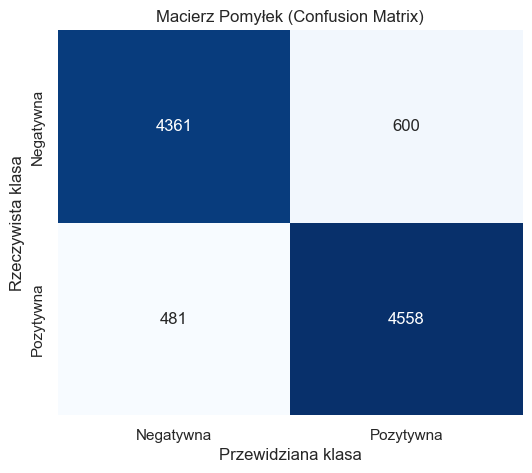

In [45]:
#trenujemy model
model = LogisticRegression(random_state=42, max_iter=1000)

#na danych treningowych
model.fit(X_train_tfidf, y_train)

#dokonywanie predykcji
y_pred = model.predict(X_test_tfidf)

#ewalujacja
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Dokładność modelu (Accuracy): {accuracy*100:.2f}%\n")

print("Szczegółowy raport klasyfikacji")
print(classification_report(y_test, y_pred, target_names=['Negatywna', 'Pozytywna']))

#wizualizacja macierzy pomyłek
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negatywna', 'Pozytywna'],
            yticklabels=['Negatywna', 'Pozytywna'])
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.title('Macierz Pomyłek (Confusion Matrix)')
plt.show()

### zad 5

--- Wyniki Modelu ---
Dokładność (Accuracy): 0.8919
Precyzja (Precision):  0.8837
Czułość (Recall):      0.9045
F1-Score:              0.8940


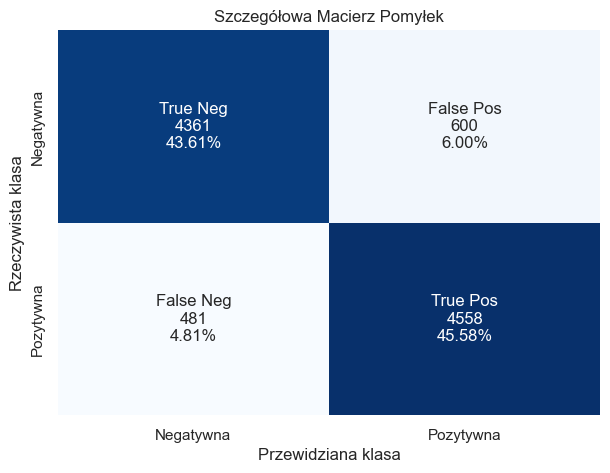

In [46]:
#obliczanie metryk
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred) 
recall = recall_score(y_test, y_pred)      
f1 = f1_score(y_test, y_pred)

print(f"--- Wyniki Modelu ---")
print(f"Dokładność (Accuracy): {accuracy:.4f}")
print(f"Precyzja (Precision):  {precision:.4f}")
print(f"Czułość (Recall):      {recall:.4f}")
print(f"F1-Score:              {f1:.4f}")

#macierz pomyłek
cm = confusion_matrix(y_test, y_pred)

# Definiujemy etykiety dla wykresu
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Negatywna', 'Pozytywna'],
            yticklabels=['Negatywna', 'Pozytywna'])
plt.title('Szczegółowa Macierz Pomyłek')
plt.ylabel('Rzeczywista klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

Model osiągnął wysoką dokładność 89,19%, co pokazuje stabilną zdolność generalizacji na zbiorze testowym. Równomierny rozkład metryk precyzji i czułości (F1-score ~0.89) dla obu klas potwierdza brak istotnego obciążenia, co świadczy o skutecznej separacji cech przez algorytm. Uzyskane wyniki wskazują na wysoką wiarygodność klasyfikatora.

### zad 6

In [47]:
#tworzenie własnych recenzji
my_reviews = [

    "What a fantastic movie. I loved every single minute of it. Everyone must watch it!",

    "Terrible movie, I feel genuine hatred towards this movie. Worst 2 hours of my life. I am nothing but disgusted.",

    "This is one of the movies created. It was okay. Actors were in the movie, and the director directed the movie as well. On top of that, this movie had an ending."

]

#przetwarzanie danych
clean_new_reviews = [clean_review(r) for r in my_reviews]

#wektoryzacja
new_reviews_tfidf = tfidf.transform(clean_new_reviews)

#predykcja
predictions = model.predict(new_reviews_tfidf)

#wyznaczanie prawdopodobieństwa
probs = model.predict_proba(new_reviews_tfidf)

#wizualizacja wyników
print(f"{'RECENZJA':<80} | {'WYNIK':<10} | {'PEWNOŚĆ'}")
print("-" * 110)

for i, review in enumerate(my_reviews):
    sentiment = "POZYTYWNA" if predictions[i] == 1 else "NEGATYWNA"
    
    #prawdopodobieństwo bycia klasą pozytywną
    confidence = probs[i][1] 
    
    display_review = (review[:75] + '..') if len(review) > 75 else review
    
    print(f"{display_review:<80} | {sentiment:<10} | {confidence:.2%}")

RECENZJA                                                                         | WYNIK      | PEWNOŚĆ
--------------------------------------------------------------------------------------------------------------
What a fantastic movie. I loved every single minute of it. Everyone must wa..    | POZYTYWNA  | 94.16%
Terrible movie, I feel genuine hatred towards this movie. Worst 2 hours of ..    | NEGATYWNA  | 1.24%
This is one of the movies created. It was okay. Actors were in the movie, a..    | POZYTYWNA  | 52.99%


Model działał dokładnie tak jak zakładano. Pozytywna i negatywna opinia zostały poprawnie sklasyfikowane z odpowiednio dużą pewnością, a neutralna zwróciła wysoką pewność bliską 50%, co było zgodne z założeniami.